# 1. Introdução

# Modelos avançados
## Projeto: Credit Risk - Home Credit Default Risk

Após a construção do modelo baselne por meio da Regressão Logística, foi identificado que o principal desafio do projeto está reloacionado ao forte desbalancemaneto da variável target e à dificuldade de identificação da classe inadimplente.

Este notebook tem como objetivo explorar técnicas e modelos mais robustos, buscando melhorar a capacidade de discriminação entre cleintes adimplentes e inadimplentes.

# 2. Bibliotecas

In [1]:
# MANIPULAÇÃO DE DADOS
import pandas as pd
import numpy as np

# GRÁFICOS
import matplotlib.pyplot as plt

# METRICAS DE DECISÃO e SMOTE para teste de balanceamento das classes
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# MACHINE LEARNING
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 3. Carregamento dos Dados Processados


In [2]:
# Features
features_processed = pd.read_parquet('../data/processed/Features_processed.parquet')
# Target
target_processed = pd.read_parquet('../data/processed/Target_processed.parquet')
# APLICANDO A FUNÇÃO RAVEL() NOS VALORES DO TARGET PARA CONVERTER PARA UM COLUNA 1D
target_processed_corrigido = target_processed.values.ravel()

# 4. Divisão Treino/Teste

In [3]:
# DIVIDINDO OS DADOS ENTRE TREINO E TESTE
x_treino, x_teste, y_treino, y_teste = train_test_split(features_processed, target_processed_corrigido, shuffle = True, test_size = 0.3, random_state  = 0, stratify = target_processed_corrigido)

# 5. Tratamento do Desbalanceamento

O modelo baseline demonstrou elevado dificuldade em identificar clientes inadimplentes, evidenciado a necessidade de estratégias específicas para lidar com o desbalancemanto da variável target.

## 5.0 Balanced

In [10]:
# CRIAÇÃO DO MODELO
modelo_balanceado = LogisticRegression(max_iter = 1500, random_state = 0, class_weight = 'balanced')
# TREINANDO O MODELO
modelo_balanceado.fit(x_treino,  y_treino)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,0
,solver,'lbfgs'
,max_iter,1500
,multi_class,'deprecated'


### 5.1 Previsões do modelo

Nesta etapa é realizada as previsões do modelo e suas probabilidades

In [14]:
# REALIZANDO AS PREVISÕES
y_pred_bal = modelo_balanceado.predict(x_teste)
# OBTENDO A PROBABILIDADE DE CADA PREVISÃO
y_proba_bal = modelo_balanceado.predict_proba(x_teste)[:,1]

# REALIZANDO AS PREVISÕES
print('Previsões feitas pelo modelo:{}'.format(modelo_balanceado.predict(x_teste)))
# OBTENDO A PROBABILIDADE DE CADA PREVISÃO
print('Probabilidade das previsões:{}'.format(modelo_balanceado.predict_proba(x_teste)[:,1]))

Previsões feitas pelo modelo:[1 1 0 ... 0 1 0]
Probabilidade das previsões:[0.52667308 0.62865341 0.44219437 ... 0.33838795 0.61067679 0.33906219]


### 5.2 Classification_report

In [16]:
print(classification_report(y_teste, modelo_balanceado.predict(x_teste)))

              precision    recall  f1-score   support

           0       0.94      0.60      0.73     84806
           1       0.11      0.57      0.19      7448

    accuracy                           0.60     92254
   macro avg       0.53      0.59      0.46     92254
weighted avg       0.87      0.60      0.69     92254



### 5.3 Matriz de Confusão

In [18]:
print(confusion_matrix(y_teste, modelo_balanceado.predict(x_teste)))

[[50630 34176]
 [ 3178  4270]]


### 5.4 ROC AUC

In [33]:
print(roc_auc_score(y_teste, modelo_balanceado.predict(x_teste)))

0.5851589581103195


## Interpretação dos Resultados

A aplicação do parâmetro class_weight='balanced' promoveu uma mudança significativa no comportamento do modelo.

Diferentemente do modelo baseline, que classificava praticamente todas as observações como adimplentes, a nova abordagem foi capaz de identificar aproximadamente 57% dos clientes inadimplentes presentes no conjunto de teste.

Esse resultado evidencia que o forte desbalanceamento da variável target exercia impacto relevante sobre a capacidade de identificação da classe positiva.

Embora tenha ocorrido uma redução na acurácia global do modelo e na precisão da classe inadimplente, observa-se um aumento expressivo do recall, métrica considerada especialmente relevante em problemas de risco de crédito.

Os resultados demonstram que a ponderação das classes contribui para tornar o modelo mais sensível à identificação de clientes inadimplentes, ainda que ao custo de um aumento na quantidade de falsos positivos.

## 5.5 SMOTE

In [26]:
# CRIANDO O SMOTE
smote = SMOTE(random_state = 0)
x_treino_smote, y_treino_smote = smote.fit_resample(
    x_treino,
    y_treino
)
# CONVERTENDO EM SERIES PARA OBSERVAR A QUANTIDADE DE CADA CLASSE PÓS APLICAR SMOTE
pd.Series(y_treino_smote).value_counts()

0    197880
1    197880
Name: count, dtype: int64

In [28]:
# CRIANDO O MODELO DE REGRESSÃO LOGISTICA
modelo_smote = LogisticRegression(
    max_iter = 5000,
    random_state = 0
)
# TREINANDO O MODELO COM OS DADOS DE TREINO PÓS SMOTE
modelo_smote.fit(x_treino_smote, y_treino_smote)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


### 5.6 Previsões do Modelo

In [35]:
# REALIZANDO AS PREVISÕES DO MODELO COM SMOTE
y_pred_smote = modelo_smote.predict(x_teste)
# EXTRAINDO AS PROBABILIDADES DAS PREVISÕES
y_proba_smote = modelo_smote.predict_proba(x_teste)[:,1]

print(y_pred_smote)
print(y_proba_smote)

[0 1 1 ... 0 1 0]
[0.28092654 0.57170469 0.5558852  ... 0.08874181 0.71141685 0.11624669]


### 5.7 Classification Report

In [36]:
print(classification_report(y_teste, y_pred_smote))

              precision    recall  f1-score   support

           0       0.93      0.65      0.76     84806
           1       0.10      0.44      0.16      7448

    accuracy                           0.63     92254
   macro avg       0.51      0.54      0.46     92254
weighted avg       0.86      0.63      0.71     92254



### 5.8 Matriz de Confusão

In [37]:
print(confusion_matrix(y_teste, y_pred_smote))

[[54978 29828]
 [ 4195  3253]]


### 5.9 ROC-AUC SCORE

In [50]:
print(roc_auc_score(y_teste, y_proba_smote))

0.5703834204980075


## Comparação entre Estratégias de Balanceamento
Foram avaliadas duas estratégias para lidar com o forte desbalanceamento da variável target: a ponderação automática das classes (class_weight='balanced') e a técnica de oversampling sintético SMOTE.

A abordagem baseada em ponderação das classes apresentou os melhores resultados para o objetivo do projeto. O modelo foi capaz de identificar aproximadamente 57% dos clientes inadimplentes, representando uma evolução significativa em relação ao modelo baseline, que não identificava nenhum inadimplente.

Embora a aplicação do SMOTE tenha promovido um pequeno aumento na acurácia global do modelo, observou-se redução na capacidade de identificação da classe inadimplente, com recall de aproximadamente 44%.

Além disso, o desempenho medido pela métrica AUC-ROC também foi inferior ao obtido pela estratégia de ponderação das classes, indicando menor capacidade de separação entre clientes adimplentes e inadimplentes.

Os resultados sugerem que, para a Regressão Logística e para a estrutura atual dos dados, a estratégia class_weight='balanced' apresentou melhor equilíbrio entre discriminação e identificação da classe positiva.

# 6. Random Forest

Após avaliar diferentes estratégias para lidar com o desbalanceamento das classes em conjunto com a Regressão Logística, será explorado o algoritmo Random Forest.

Por se tratar de um modelo baseado em árvores de decisão, o Random Forest é capaz de capturar relações não lineares entre as variáveis, podendo identificar padrões mais complexos associados ao risco de inadimplência.

O objetivo desta etapa é verificar se um modelo mais robusto consegue melhorar a capacidade de identificação da classe inadimplente em relação aos modelos avaliados anteriormente.


In [41]:
# CRIAÇÃO DO MODELO
modelo_rf = RandomForestClassifier(n_estimators = 200, random_state = 0, class_weight = 'balanced', n_jobs = -1)
# TREINAMENTO DO MODELO
modelo_rf.fit(x_treino, y_treino)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 6.1 Previsões do Modelo

In [44]:
# REALIZANDO AS PREVISÕES
y_pred_rf = modelo_rf.predict(x_teste)
# OBTENDO A PROBABILIDADE DE CADA PREVISÃO
y_proba_rf = modelo_rf.predict_proba(x_teste)[:,1]

print(f'Previsões feitas pelo modelo: {y_pred_rf}')
print(f'Probabilidade das previsões: {y_proba_rf}')

Previsões feitas pelo modelo: [0 0 0 ... 0 0 0]
Probabilidade das previsões: [0.145 0.115 0.055 ... 0.025 0.205 0.055]


## 6.2 Classification Report

In [62]:
print(classification_report(y_teste, y_pred_rf))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     84806
           1       0.69      0.00      0.00      7448

    accuracy                           0.92     92254
   macro avg       0.80      0.50      0.48     92254
weighted avg       0.90      0.92      0.88     92254



## 6.3 Matriz de confusão

In [46]:
print(confusion_matrix(y_teste, y_pred_rf))

[[84801     5]
 [ 7437    11]]


## 6.4 ROC AUC SCORE

In [49]:
print(roc_auc_score(y_teste, y_proba_rf))

0.7313660716074722


## 6.5 ROC CURVE

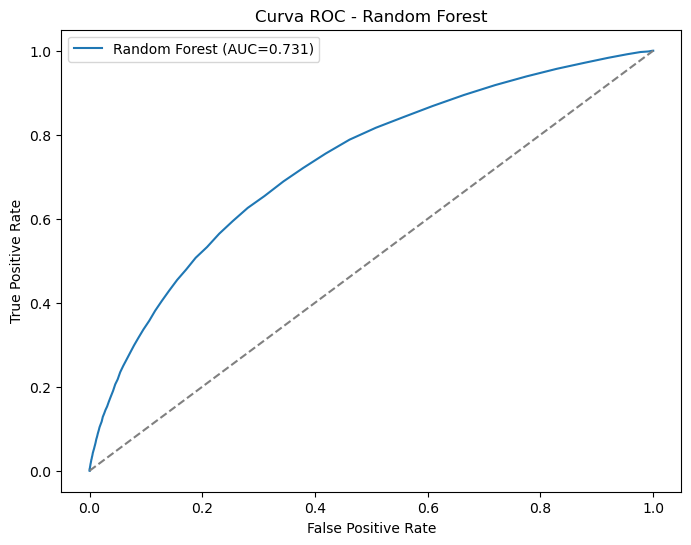

In [57]:
# CURVA ROC
fpr, tpr, thresholds = roc_curve(
    y_teste,
    y_proba_rf
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'Random Forest (AUC={roc_auc_score(y_teste, y_proba_rf):.3f})'
)

plt.plot(
    [0,1],
    [0,1],
    '--',
    color='gray'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Random Forest')
plt.legend()

plt.show()

## 6.6 Precision-Recall Curve

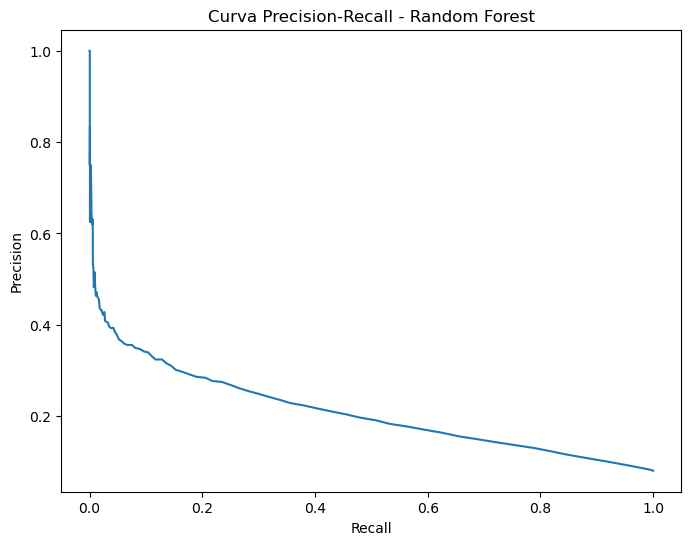

In [56]:
# CURVA DA PRECISÃO ~ RECALL
precision, recall, thresholds = precision_recall_curve(
    y_teste,
    y_proba_rf
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision
)

plt.xlabel('Recall')
plt.ylabel('Precision')

plt.title('Curva Precision-Recall - Random Forest')

plt.show()

## 6.7 AJUSTES DE THRESHOLD

In [61]:
for threshold in [0.10,0.15,0.20,0.25,0.30]:
    y_pred_custom = (y_proba_rf >= threshold).astype(int)
    print(f"Threshold:{threshold}")
    print(classification_report(y_teste, y_pred_custom))

Threshold:0.1
              precision    recall  f1-score   support

           0       0.95      0.75      0.84     84806
           1       0.17      0.59      0.26      7448

    accuracy                           0.73     92254
   macro avg       0.56      0.67      0.55     92254
weighted avg       0.89      0.73      0.79     92254

Threshold:0.15
              precision    recall  f1-score   support

           0       0.94      0.90      0.92     84806
           1       0.24      0.34      0.28      7448

    accuracy                           0.86     92254
   macro avg       0.59      0.62      0.60     92254
weighted avg       0.88      0.86      0.87     92254

Threshold:0.2
              precision    recall  f1-score   support

           0       0.93      0.96      0.95     84806
           1       0.29      0.18      0.22      7448

    accuracy                           0.90     92254
   macro avg       0.61      0.57      0.58     92254
weighted avg       0.88      0.

## Avaliação do Random Forest
Inicialmente, o Random Forest apresentou desempenho semelhante ao modelo baseline quando avaliado utilizando o threshold padrão de 0,50, classificando a maior parte das observações como adimplentes.

Entretanto, a análise das probabilidades previstas demonstrou elevada capacidade de separação entre as classes, refletida pelo AUC-ROC de aproximadamente 0,73, o melhor resultado obtido até o momento.

Ajustando o threshold de classificação para 0,10, observou-se aumento significativo da capacidade de identificação dos clientes inadimplentes, atingindo aproximadamente 59% de recall para a classe positiva.

Esse resultado evidencia que o modelo possuía forte capacidade discriminatória, mas que o threshold padrão ocultava parte do seu potencial preditivo.

# 7. XGBoost

Após a avaliação da Regressão Logística e da Random Forest, será explorado o algoritmo XGBoost (Extreme Gradient Boosting).

O XGBoost é amplamente utilizado em problemas de risco de crédito por sua capacidade de capturar padrões complexos e realizar aprendizado sequencial, corrigindo erros cometidos por árvores anteriores.

Além disso, o algoritmo permite lidar com desbalanceamento de classes por meio do parâmetro scale_pos_weight, tornando-se uma alternativa promissora para melhorar a identificação de clientes inadimplentes.

In [15]:
y_treino_series = pd.Series(y_treino)
print('Frequência em cada classe')
display(y_treino_series.value_counts())
print(f'Razão entre adimplente e inadimplente para utilizar como hiperparametro de scale_pos_wight:{197880 / 17377:.2f}')

Frequência em cada classe


0    197880
1     17377
Name: count, dtype: int64

Razão entre adimplente e inadimplente para utilizar como hiperparametro de scale_pos_wight:11.39


In [17]:
modelo_xgb = XGBClassifier(n_estimators = 300, random_state = 0, max_depth = 6, learning_rate = 0.05, 
                               scale_pos_weight = 11.39, eval_metric = 'logloss', n_jobs = -1)
modelo_xgb.fit(x_treino, y_treino)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


## 7.1 Previsões do modelo

In [18]:
y_pred_xgb = modelo_xgb.predict(x_teste)
y_proba_xgb = modelo_xgb.predict_proba(x_teste)[:,1]
print(f'Predições feitas pelo modelo: {y_pred_xgb}')
print(f'Probabilidade das predições: {y_proba_xgb}')

Predições feitas pelo modelo: [1 1 0 ... 0 1 0]
Probabilidade das predições: [0.66382056 0.67020404 0.3313439  ... 0.44903702 0.73624986 0.39984274]


## 7.2 Classification Report

In [21]:
print(classification_report(y_teste, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.96      0.74      0.83     84806
           1       0.18      0.65      0.28      7448

    accuracy                           0.73     92254
   macro avg       0.57      0.69      0.56     92254
weighted avg       0.90      0.73      0.79     92254



## 7.3 Confusion Matrix

In [23]:
print(confusion_matrix(y_teste, y_pred_xgb))

[[62398 22408]
 [ 2625  4823]]


## 7.4 AUC-ROC SCORE

In [24]:
print(roc_auc_score(y_teste, y_proba_xgb))

0.7583249792481447


## 7.5 CURVA ROC

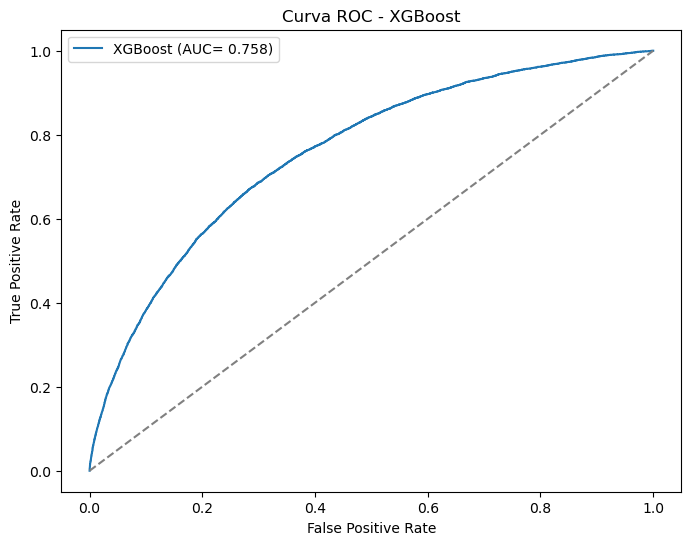

In [30]:
fpr, tpr, _ = roc_curve(
    y_teste,
    y_proba_xgb
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'XGBoost (AUC= {roc_auc_score(y_teste, y_proba_xgb):.3f})'
)

plt.plot(
    [0,1],
    [0,1],
    '--',
    color='gray'
)

plt.legend()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - XGBoost')

plt.show()

## 7.6 Curva Precision-Recall

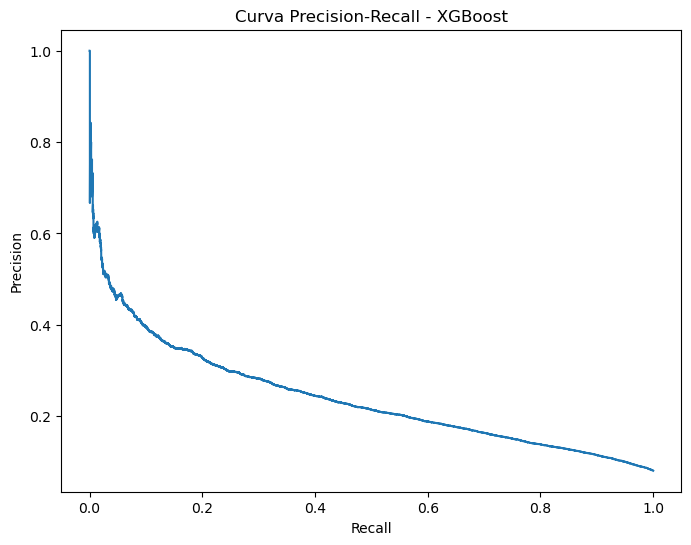

In [31]:
precision, recall, _ = precision_recall_curve(
    y_teste,
    y_proba_xgb
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision
)

plt.xlabel('Recall')
plt.ylabel('Precision')

plt.title('Curva Precision-Recall - XGBoost')

plt.show()

## Interpretação dos Resultados
O XGBoost apresentou o melhor desempenho entre todos os modelos avaliados até o momento.

A capacidade de separação entre clientes adimplentes e inadimplentes atingiu aproximadamente 75,8%, medida pelo AUC-ROC, representando o maior poder discriminatório observado no projeto.

Além disso, o modelo foi capaz de identificar aproximadamente 65% dos clientes inadimplentes presentes no conjunto de teste, superando tanto a Regressão Logística balanceada quanto a Random Forest com threshold ajustado.

Observou-se também melhora na precisão da classe inadimplente, indicando que o modelo não apenas encontrou mais clientes de risco, mas também realizou previsões mais consistentes.

A análise das probabilidades previstas sugere que o XGBoost produz scores mais bem distribuídos entre as classes, favorecendo uma melhor separação dos perfis de risco e contribuindo para o aumento do AUC-ROC.

Os resultados indicam que o XGBoost se tornou o principal candidato para as próximas etapas de otimização e ajuste de hiperparâmetros.

# 8. Visualização Comparativa

A comparação dos modelos evidencia a forte influência do tratamento do desbalanceamento e da escolha do algoritmo sobre o desempenho do sistema de classificação.

O modelo baseline demonstrou capacidade limitada de identificação da classe inadimplente, apesar da elevada acurácia observada.

A utilização do parâmetro class_weight='balanced' promoveu aumento expressivo do recall da classe positiva, evidenciando o impacto do desbalanceamento sobre o treinamento.

A aplicação do SMOTE não apresentou ganhos relevantes neste contexto, resultando em desempenho inferior ao obtido pela ponderação automática das classes.

O Random Forest apresentou elevada capacidade de separação entre as classes, resultado evidenciado pelo AUC-ROC superior a 70%, mas necessitou de ajuste do threshold de classificação para converter esse potencial em capacidade efetiva de identificação dos inadimplentes.

Por fim, o XGBoost apresentou o melhor equilíbrio entre Recall, Precision e AUC-ROC, tornando-se o modelo com melhor desempenho geral entre os algoritmos avaliados.

,Accuracy,Recall Classe 1,Precision Classe 1,AUC
Logistic Baseline,0.92,0.00,0.00,0.630
Logistic Balanced,0.60,0.57,0.11,0.585
Logistic + SMOTE,0.63,0.44,0.10,0.570
Random Forest (Threshold 0.10),0.73,0.59,0.17,0.731
XGBoost,0.73,0.65,0.18,0.758


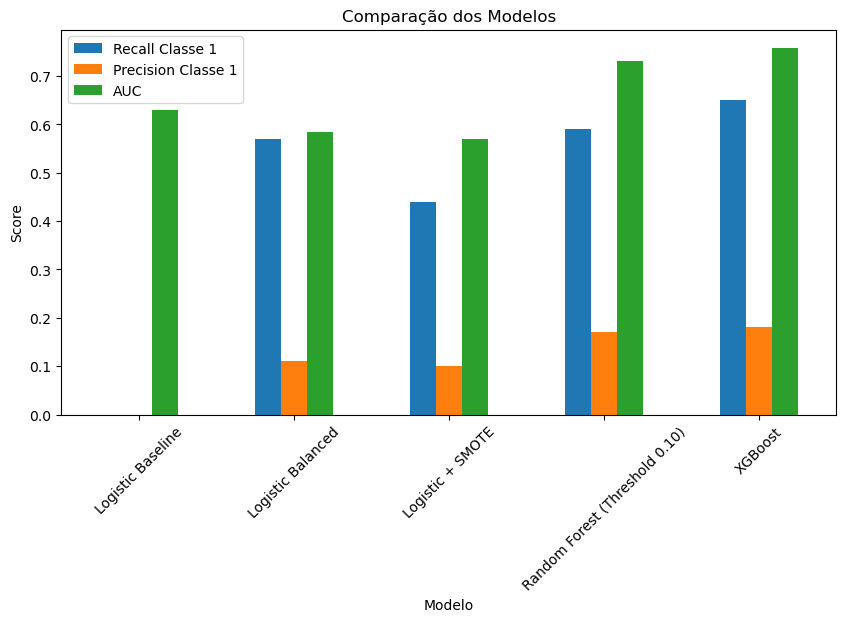

In [35]:
resultados = {
    'Logistic Baseline': {
        'Accuracy': 0.92,
        'Recall Classe 1': 0.00,
        'Precision Classe 1': 0.00,
        'AUC': 0.63
    },

    'Logistic Balanced': {
        'Accuracy': 0.60,
        'Recall Classe 1': 0.57,
        'Precision Classe 1': 0.11,
        'AUC': 0.585
    },

    'Logistic + SMOTE': {
        'Accuracy': 0.63,
        'Recall Classe 1': 0.44,
        'Precision Classe 1': 0.10,
        'AUC': 0.57
    },

    'Random Forest (Threshold 0.10)': {
        'Accuracy': 0.73,
        'Recall Classe 1': 0.59,
        'Precision Classe 1': 0.17,
        'AUC': 0.731
    },

    'XGBoost': {
        'Accuracy': 0.73,
        'Recall Classe 1': 0.65,
        'Precision Classe 1': 0.18,
        'AUC': 0.758
    }
}

df_resultados = pd.DataFrame(resultados).T

display(df_resultados)

df_resultados[['Recall Classe 1',
               'Precision Classe 1',
               'AUC']].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Comparação dos Modelos')
plt.ylabel('Score')
plt.xlabel('Modelo')
plt.xticks(rotation=45)

plt.show()

# 9. Conclusões

A etapa de modelagem avançada demonstrou que a variável target apresenta desbalanceamento suficiente para afetar significativamente o desempenho dos algoritmos de classificação.

O uso de técnicas de balanceamento mostrou-se fundamental para aumentar a capacidade de identificação da classe inadimplente, especialmente por meio da estratégia class_weight='balanced'.

A técnica SMOTE não apresentou ganhos relevantes para a Regressão Logística, evidenciando que nem toda estratégia de balanceamento produz melhorias automáticas de desempenho.

A análise da Random Forest demonstrou que modelos com elevada capacidade de separação podem apresentar desempenho insatisfatório quando avaliados com thresholds inadequados, reforçando a importância da calibração dos limiares de decisão.

Entre os modelos avaliados, o XGBoost apresentou o melhor equilíbrio entre capacidade de separação das classes, identificação dos inadimplentes e precisão das previsões, sendo selecionado como principal candidato para as próximas etapas do projeto.

# 10. Próximo Passos

Com base nos resultados obtidos, as próximas etapas do projeto incluem:

- Otimização dos hiperparâmetros do XGBoost.
- Aplicação de validação cruzada para avaliação da estabilidade do modelo.
- Ajuste dos thresholds de classificação visando melhorar o equilíbrio entre Recall e Precision.
- Análise da importância das variáveis para identificação dos principais fatores associados à inadimplência.
- Consolidação dos resultados e elaboração das conclusões de negócio.
